In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load your dataset
df = pd.read_csv("records.csv")

# Preview
df.head()

,name,record
0,abc.example.com,1.1.1.1
1,abc.example.com,1.2.2.2
2,def.example.com,52.54.24.193


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    3 non-null      str  
 1   record  3 non-null      str  
dtypes: str(2)
memory usage: 251.0 bytes


name      0
record    0
dtype: int64

In [6]:
# Fill missing values
df = df.ffill()

# Ensure modern dtypes
df = df.convert_dtypes()

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='string').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array([[1, 2], [3, 4], [5, 6]])
y = np.array([0, 1, 0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred_dt))

[[0 1]
 [0 0]]


In [12]:
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



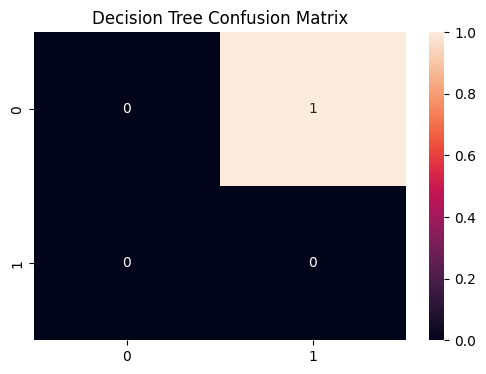

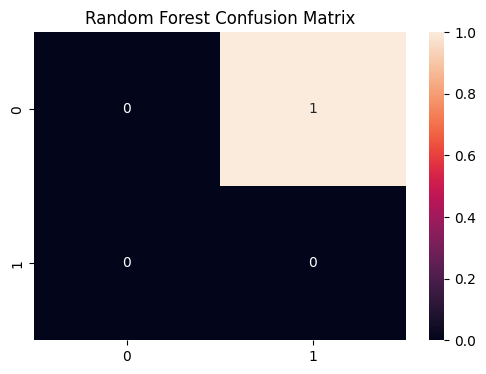

In [13]:
# Decision Tree
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

     Feature  Importance
0  Feature_0         0.5
1  Feature_1         0.5


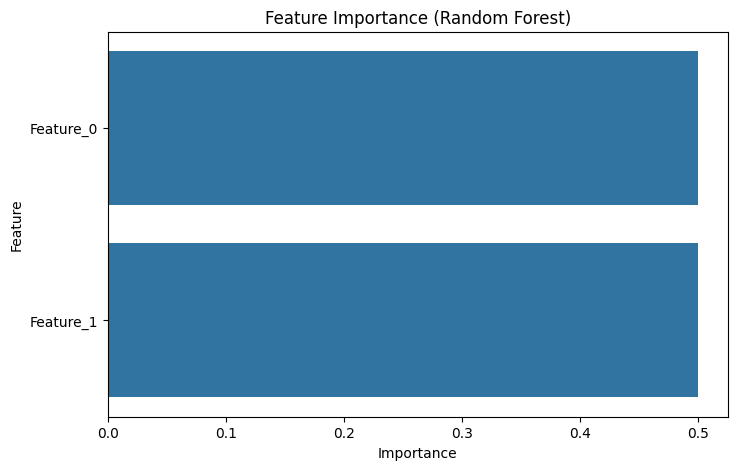

In [15]:
importances = rf_model.feature_importances_

# Replace this with correct feature names
features = [f'Feature_{i}' for i in range(X.shape[1])]

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_df)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance (Random Forest)")
plt.show()